# 0. Configuração

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
df = pd.read_csv('../../data/df_casa.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

# 1. Limpeza e padronização


In [4]:
df_limpo = df.copy()

In [5]:
#renomeando colunas
df_limpo = df_limpo.rename(columns={
    'id': 'id_imovel',
    'date': 'data',
    'price': 'preco',
    'bedrooms': 'quartos',
    'bathrooms': 'banheiros',
    'sqft_living': 'area_construida_ft2',
    'sqft_above': 'area_acima_solo_ft2',
    'sqft_basement': 'area_porao_ft2',
    'sqft_lot': 'area_terreno_ft2',
    'floors': 'andares',
    'waterfront': 'vista_agua',
    'view': 'qualidade_vista',
    'grade': 'padrao_construcao',
    'condition': 'condicao_imovel',
    'yr_built': 'ano_construcao',
    'yr_renovated': 'ano_reforma',
    'zipcode': 'cep',
    'lat': 'latitude',
    'long': 'longitude',
    'sqft_living15': 'area_construida_vizinhos_ft2',
    'sqft_lot15': 'area_terreno_vizinhos_ft2'
})


In [6]:
df_limpo.columns


Index(['id_imovel', 'data', 'preco', 'quartos', 'banheiros',
       'area_construida_ft2', 'area_terreno_ft2', 'andares', 'vista_agua',
       'qualidade_vista', 'condicao_imovel', 'padrao_construcao',
       'area_acima_solo_ft2', 'area_porao_ft2', 'ano_construcao',
       'ano_reforma', 'cep', 'latitude', 'longitude',
       'area_construida_vizinhos_ft2', 'area_terreno_vizinhos_ft2'],
      dtype='str')

In [7]:
df_limpo['data'] = pd.to_datetime(df_limpo['data'])
df_limpo.dtypes

id_imovel                                int64
data                            datetime64[us]
preco                                  float64
quartos                                  int64
banheiros                              float64
area_construida_ft2                      int64
area_terreno_ft2                         int64
andares                                float64
vista_agua                               int64
qualidade_vista                          int64
condicao_imovel                          int64
padrao_construcao                        int64
area_acima_solo_ft2                      int64
area_porao_ft2                           int64
ano_construcao                           int64
ano_reforma                              int64
cep                                      int64
latitude                               float64
longitude                              float64
area_construida_vizinhos_ft2             int64
area_terreno_vizinhos_ft2                int64
dtype: object

In [8]:
#convertendo de pés quadrados para metros quadrados
cols = ['area_construida_ft2', 'area_terreno_ft2', 'area_acima_solo_ft2', 'area_porao_ft2', 'area_construida_vizinhos_ft2','area_terreno_vizinhos_ft2']
for col in cols:
    df_limpo[col] = pd.to_numeric(df_limpo[col], errors = 'coerce')
    df_limpo[col] = df_limpo[col] / 10.76389999
df_limpo.rename(columns = {'area_construida_ft2': 'area_construida_m2',
                           'area_terreno_ft2': 'area_terreno_m2',
                           'area_acima_solo_ft2': 'area_acima_solo_m2',
                             'area_porao_ft2' : 'area_porao_m2',
                             'area_construida_vizinhos_ft2': 'area_construida_vizinhos_m2',
                              'area_terreno_vizinhos_ft2' : 'area_terreno_vizinhos_m2'
                              }, inplace = True)    

In [9]:
df_limpo.isnull().sum()

id_imovel                      0
data                           0
preco                          0
quartos                        0
banheiros                      0
area_construida_m2             0
area_terreno_m2                0
andares                        0
vista_agua                     0
qualidade_vista                0
condicao_imovel                0
padrao_construcao              0
area_acima_solo_m2             0
area_porao_m2                  0
ano_construcao                 0
ano_reforma                    0
cep                            0
latitude                       0
longitude                      0
area_construida_vizinhos_m2    0
area_terreno_vizinhos_m2       0
dtype: int64

In [10]:
#olhando os minimos para verificar se há inconsistencias
col_numericas = df_limpo.select_dtypes(include = ['float64', 'int64']).columns
(df_limpo[col_numericas]).min()

id_imovel                      1.000102e+06
preco                          7.500000e+04
quartos                        0.000000e+00
banheiros                      0.000000e+00
area_construida_m2             2.694191e+01
area_terreno_m2                4.830963e+01
andares                        1.000000e+00
vista_agua                     0.000000e+00
qualidade_vista                0.000000e+00
condicao_imovel                1.000000e+00
padrao_construcao              1.000000e+00
area_acima_solo_m2             2.694191e+01
area_porao_m2                  0.000000e+00
ano_construcao                 1.900000e+03
ano_reforma                    0.000000e+00
cep                            9.800100e+04
latitude                       4.715590e+01
longitude                     -1.225190e+02
area_construida_vizinhos_m2    3.706835e+01
area_terreno_vizinhos_m2       6.047994e+01
dtype: float64

In [11]:
df_limpo.to_csv('../../data/df_limpo.csv', index = False)
df_limpo.info()
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assuming 'cdata' is a pandas DataFrame
# sns.pairplot(df_limpo, diag_kind='kde')
# plt.show()

#df_limpo.corr()


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_imovel                    21613 non-null  int64         
 1   data                         21613 non-null  datetime64[us]
 2   preco                        21613 non-null  float64       
 3   quartos                      21613 non-null  int64         
 4   banheiros                    21613 non-null  float64       
 5   area_construida_m2           21613 non-null  float64       
 6   area_terreno_m2              21613 non-null  float64       
 7   andares                      21613 non-null  float64       
 8   vista_agua                   21613 non-null  int64         
 9   qualidade_vista              21613 non-null  int64         
 10  condicao_imovel              21613 non-null  int64         
 11  padrao_construcao            21613 non-null  int64  

# 2. Consultas e agregações

In [12]:
df_analise = pd.read_csv('../../data/df_limpo.csv', parse_dates = ['data'])

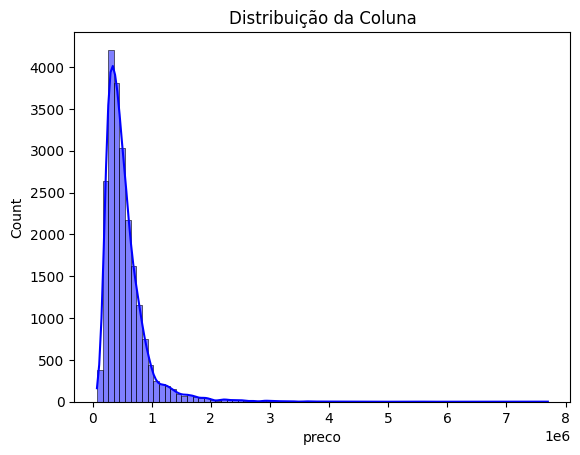

In [13]:
#Plotando a distribuição com a estimação de densidade de kernel(gabarito)
sns.histplot(df_analise['preco'], kde=True, bins=80, color= 'blue')
plt.title('Distribuição da Coluna')
plt.show()


In [14]:
meses_pt = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril',
    5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
    9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}

In [15]:
df_analise['ano'] = df_analise['data'].dt.year
df_2014 = df_analise[df_analise['ano'] == 2014]
df_2014['mes_num'] = df_2014['data'].dt.month
df_2014['mes_nome'] = df_2014['mes_num'].map(meses_pt)
medias_2014 = df_2014.groupby(['mes_num','mes_nome'])['preco'].mean().reset_index() # analisar esse bloco
medias_2014 = medias_2014.sort_values('mes_num')
print(medias_2014)

   mes_num  mes_nome          preco
0        5      Maio  548080.276584
1        6     Junho  558002.199541
2        7     Julho  544788.764360
3        8    Agosto  536445.276804
4        9  Setembro  529253.821871
5       10   Outubro  539031.977103
6       11  Novembro  521961.009213
7       12  Dezembro  524461.866757


In [16]:
fig = px.line(medias_2014, x = 'mes_nome',
               y = 'preco',
               title = 'Média de Preços de Casas por Mês (Ano 2014)',
               labels = {'mes_nome': 'MÊS', 'preco' : 'PREÇO MÉDIO (USD)'}, markers = True)
fig.update_layout(font_family = "Times New Roman", title_font_family = "Courier New", xaxis = dict(tickmode = 'linear', tick0 = 1, dtick = 1))
fig.show()

In [17]:
df_2015 = df_analise[df_analise['ano']== 2015]
df_2015['mes_num'] = df_2015['data'].dt.month
df_2015['mes_nome'] = df_2015['mes_num'].map(meses_pt)
medias_2015 = df_2015.groupby(['mes_num', 'mes_nome'])['preco'].mean().reset_index() # analisar esse bloco
medias_2015 = medias_2015.sort_values('mes_num')
print(medias_2015)

   mes_num   mes_nome          preco
0        1    Janeiro  525870.889571
1        2  Fevereiro  507851.371200
2        3      Março  543977.187200
3        4      Abril  561837.774989
4        5       Maio  558126.811146


In [18]:
fig = px.line(medias_2015,x = 'mes_nome', y = 'preco', title = 'Média de preços por mes no ano de 2015', labels = {'mes_nome': 'Mês', 'preco': 'Preço médio(USD)'},markers = True)
fig.update_layout(font_family = "Courier New", title_font_family = 'Times New Roman', xaxis = dict(tickmode = 'linear', tick0 = 1, dtick = 1))
fig.show()


In [19]:
df_analise.to_csv('../../data/df_analise.csv', index = False)

# 3. Analise estatistica

In [20]:
df_estatistica = pd.read_csv('../../data/df_analise.csv', parse_dates = ['data'])

In [21]:
fig = px.box(df_estatistica, y = 'preco', title = 'Boxplot Interativo de preços')
fig.show()

In [22]:
fig = px.scatter(df_estatistica, x = 'area_construida_m2', y = 'preco', title = 'Gráfico de dispersão(area construida x preço)')
fig.show()

In [23]:
analise_anual = df_estatistica.groupby('ano_construcao')['preco'].agg(['mean', 'std']).reset_index()
analise_anual.columns = ['ano_construcao', 'preco_medio', 'desvio_padrao']
analise_anual = analise_anual.sort_values('ano_construcao')



In [24]:
fig_anual = px.line(analise_anual, x = 'ano_construcao', y = 'preco_medio', title = 'Analise do preço ao longo dos anos', labels = {'ano_construcao': 'Ano de Construção', 'preco_medio': 'Preço Médio(R$)'}, hover_data = {'desvio_padrao': ':,.2f'}, markers = True) 
fig_anual.show()

In [25]:
df_estatistica.corr()

,id_imovel,data,preco,quartos,banheiros,area_construida_m2,area_terreno_m2,andares,vista_agua,qualidade_vista,...,area_acima_solo_m2,area_porao_m2,ano_construcao,ano_reforma,cep,latitude,longitude,area_construida_vizinhos_m2,area_terreno_vizinhos_m2,ano
id_imovel,1.000000,0.005576,-0.016762,0.001240,0.005158,-0.012259,-0.132109,0.018524,-0.002721,0.011592,...,-0.010843,-0.005152,0.021379,-0.016907,-0.008221,-0.001891,0.020798,-0.002903,-0.138798,0.010127
data,0.005576,1.000000,-0.004357,-0.016792,-0.034410,-0.034559,0.006313,-0.022491,0.001356,-0.001800,...,-0.027924,-0.019469,-0.000355,-0.024509,0.001404,-0.032856,-0.007020,-0.031515,0.002566,0.853452
preco,-0.016762,-0.004357,1.000000,0.308377,0.525136,0.702035,0.089661,0.256793,0.266370,0.397294,...,0.605567,0.323816,0.054011,0.126434,-0.053201,0.307003,0.021626,0.585378,0.082447,0.003575
quartos,0.001240,-0.016792,0.308377,1.000000,0.515932,0.576693,0.031713,0.175466,-0.006578,0.079543,...,0.477614,0.303112,0.154198,0.018850,-0.152754,-0.008913,0.129482,0.391666,0.029256,-0.009804
banheiros,0.005158,-0.034410,0.525136,0.515932,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,...,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175,-0.026596
area_construida_m2,-0.012259,-0.034559,0.702035,0.576693,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,...,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286,-0.029038
area_terreno_m2,-0.132109,0.006313,0.089661,0.031713,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,...,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557,0.005468
andares,0.018524,-0.022491,0.256793,0.175466,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,...,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269,-0.022315
vista_agua,-0.002721,0.001356,0.266370,-0.006578,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,...,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703,-0.004165
qualidade_vista,0.011592,-0.001800,0.397294,0.079543,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,...,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575,0.001364


In [26]:
df_estatistica['idade_imovel'] = df_estatistica['ano'] - df_estatistica['ano_construcao']
df_estatistica['proporcao_vizinhanca'] = df_estatistica['area_construida_m2']/ df_estatistica['area_construida_vizinhos_m2']
df_estatistica['densidade_banheiros'] = df_estatistica['banheiros'] / df_estatistica['quartos']

In [27]:
print(np.isinf(df_estatistica.select_dtypes(include=np.number)).sum())

id_imovel                      0
preco                          0
quartos                        0
banheiros                      0
area_construida_m2             0
area_terreno_m2                0
andares                        0
vista_agua                     0
qualidade_vista                0
condicao_imovel                0
padrao_construcao              0
area_acima_solo_m2             0
area_porao_m2                  0
ano_construcao                 0
ano_reforma                    0
cep                            0
latitude                       0
longitude                      0
area_construida_vizinhos_m2    0
area_terreno_vizinhos_m2       0
ano                            0
idade_imovel                   0
proporcao_vizinhanca           0
densidade_banheiros            6
dtype: int64


In [28]:
df_estatistica = df_estatistica.replace([np.inf, -np.inf], np.nan)
df_estatistica = df_estatistica.dropna()

In [29]:
df_estatistica.corr()

,id_imovel,data,preco,quartos,banheiros,area_construida_m2,area_terreno_m2,andares,vista_agua,qualidade_vista,...,ano_reforma,cep,latitude,longitude,area_construida_vizinhos_m2,area_terreno_vizinhos_m2,ano,idade_imovel,proporcao_vizinhanca,densidade_banheiros
id_imovel,1.000000,0.005392,-0.016713,0.001285,0.005352,-0.012133,-0.131923,0.018669,-0.002721,0.011557,...,-0.016909,-0.008166,-0.001804,0.020550,-0.002675,-0.138576,0.009921,-0.021500,-0.015203,0.010925
data,0.005392,1.000000,-0.004046,-0.016586,-0.034302,-0.034317,0.006365,-0.022359,0.001362,-0.001735,...,-0.024499,0.001563,-0.032588,-0.007149,-0.031245,0.002636,0.853470,0.013861,-0.014024,-0.023369
preco,-0.016713,-0.004046,1.000000,0.308918,0.525873,0.701910,0.089827,0.256876,0.266432,0.397326,...,0.126429,-0.053345,0.306855,0.021831,0.585288,0.082751,0.003690,-0.053955,0.302019,0.281312
quartos,0.001285,-0.016586,0.308918,1.000000,0.515030,0.578426,0.032335,0.178215,-0.006795,0.080091,...,0.018465,-0.153850,-0.009721,0.131075,0.393588,0.030485,-0.009917,-0.155959,0.427863,-0.234774
banheiros,0.005352,-0.034302,0.525873,0.515030,1.000000,0.755827,0.088184,0.502638,0.063744,0.188403,...,0.050598,-0.204400,0.024486,0.223752,0.569929,0.088036,-0.026569,-0.507493,0.454885,0.653038
area_construida_m2,-0.012133,-0.034317,0.701910,0.578426,0.755827,1.000000,0.173342,0.354071,0.103856,0.284726,...,0.055344,-0.199607,0.052266,0.240536,0.756433,0.184183,-0.029010,-0.318651,0.569966,0.311070
area_terreno_m2,-0.131923,0.006365,0.089827,0.032335,0.088184,0.173342,1.000000,-0.004861,0.021627,0.074883,...,0.007675,-0.129623,-0.085567,0.230243,0.144691,0.718212,0.005659,-0.052830,0.081978,0.063104
andares,0.018669,-0.022359,0.256876,0.178215,0.502638,0.354071,-0.004861,1.000000,0.023765,0.028851,...,0.006454,-0.059445,0.049304,0.125569,0.280192,-0.010793,-0.022352,-0.489544,0.202900,0.421244
vista_agua,-0.002721,0.001362,0.266432,-0.006795,0.063744,0.103856,0.021627,0.023765,1.000000,0.401972,...,0.092875,0.030279,-0.014297,-0.041915,0.086512,0.030773,-0.004168,0.026077,0.034813,0.080088
qualidade_vista,0.011557,-0.001735,0.397326,0.080091,0.188403,0.284726,0.074883,0.028851,0.401972,1.000000,...,0.103959,0.084648,0.005895,-0.078176,0.280699,0.072877,0.001267,0.053627,0.075511,0.131877


In [30]:
len(df_estatistica['cep'].value_counts())


70

In [31]:
df_estatistica.info()

<class 'pandas.DataFrame'>
Index: 21600 entries, 0 to 21612
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_imovel                    21600 non-null  int64         
 1   data                         21600 non-null  datetime64[us]
 2   preco                        21600 non-null  float64       
 3   quartos                      21600 non-null  int64         
 4   banheiros                    21600 non-null  float64       
 5   area_construida_m2           21600 non-null  float64       
 6   area_terreno_m2              21600 non-null  float64       
 7   andares                      21600 non-null  float64       
 8   vista_agua                   21600 non-null  int64         
 9   qualidade_vista              21600 non-null  int64         
 10  condicao_imovel              21600 non-null  int64         
 11  padrao_construcao            21600 non-null  int64       

In [32]:
df_estatistica.to_csv('../../data/df_estatistica.csv', index = False)

# 4. Machine Learning

In [33]:
df_modelo = pd.read_csv('../../data/df_estatistica.csv', parse_dates = ['data'])

In [34]:
df_modelo.shape

(21600, 25)

In [35]:
df_modelo.columns

Index(['id_imovel', 'data', 'preco', 'quartos', 'banheiros',
       'area_construida_m2', 'area_terreno_m2', 'andares', 'vista_agua',
       'qualidade_vista', 'condicao_imovel', 'padrao_construcao',
       'area_acima_solo_m2', 'area_porao_m2', 'ano_construcao', 'ano_reforma',
       'cep', 'latitude', 'longitude', 'area_construida_vizinhos_m2',
       'area_terreno_vizinhos_m2', 'ano', 'idade_imovel',
       'proporcao_vizinhanca', 'densidade_banheiros'],
      dtype='str')

In [36]:
colunas_excluir = ['id_imovel', 'data', 'area_terreno_m2', 
                   'condicao_imovel', 'ano_construcao', 'ano_reforma',
                   'cep', 'longitude', 'area_terreno_vizinhos_m2', 'ano', 'area_acima_solo_m2']
df_modelo = df_modelo.drop(columns = colunas_excluir)

In [37]:
df_modelo.corr()

,preco,quartos,banheiros,area_construida_m2,andares,vista_agua,qualidade_vista,padrao_construcao,area_porao_m2,latitude,area_construida_vizinhos_m2,idade_imovel,proporcao_vizinhanca,densidade_banheiros
preco,1.000000,0.308918,0.525873,0.701910,0.256876,0.266432,0.397326,0.667764,0.323815,0.306855,0.585288,-0.053955,0.302019,0.281312
quartos,0.308918,1.000000,0.515030,0.578426,0.178215,-0.006795,0.080091,0.357156,0.302914,-0.009721,0.393588,-0.155959,0.427863,-0.234774
banheiros,0.525873,0.515030,1.000000,0.755827,0.502638,0.063744,0.188403,0.666080,0.283534,0.024486,0.569929,-0.507493,0.454885,0.653038
area_construida_m2,0.701910,0.578426,0.755827,1.000000,0.354071,0.103856,0.284726,0.762707,0.435186,0.052266,0.756433,-0.318651,0.569966,0.311070
andares,0.256876,0.178215,0.502638,0.354071,1.000000,0.023765,0.028851,0.458790,-0.245609,0.049304,0.280192,-0.489544,0.202900,0.421244
vista_agua,0.266432,-0.006795,0.063744,0.103856,0.023765,1.000000,0.401972,0.082861,0.080564,-0.014297,0.086512,0.026077,0.034813,0.080088
qualidade_vista,0.397326,0.080091,0.188403,0.284726,0.028851,0.401972,1.000000,0.251661,0.277095,0.005895,0.280699,0.053627,0.075511,0.131877
padrao_construcao,0.667764,0.357156,0.666080,0.762707,0.458790,0.082861,0.251661,1.000000,0.168350,0.113893,0.713779,-0.448165,0.285017,0.409750
area_porao_m2,0.323815,0.302914,0.283534,0.435186,-0.245609,0.080564,0.277095,0.168350,1.000000,0.110451,0.200514,0.132746,0.393961,0.064941
latitude,0.306855,-0.009721,0.024486,0.052266,0.049304,-0.014297,0.005895,0.113893,0.110451,1.000000,0.048790,0.147873,0.020515,0.045527


In [38]:
df_modelo.columns

Index(['preco', 'quartos', 'banheiros', 'area_construida_m2', 'andares',
       'vista_agua', 'qualidade_vista', 'padrao_construcao', 'area_porao_m2',
       'latitude', 'area_construida_vizinhos_m2', 'idade_imovel',
       'proporcao_vizinhanca', 'densidade_banheiros'],
      dtype='str')

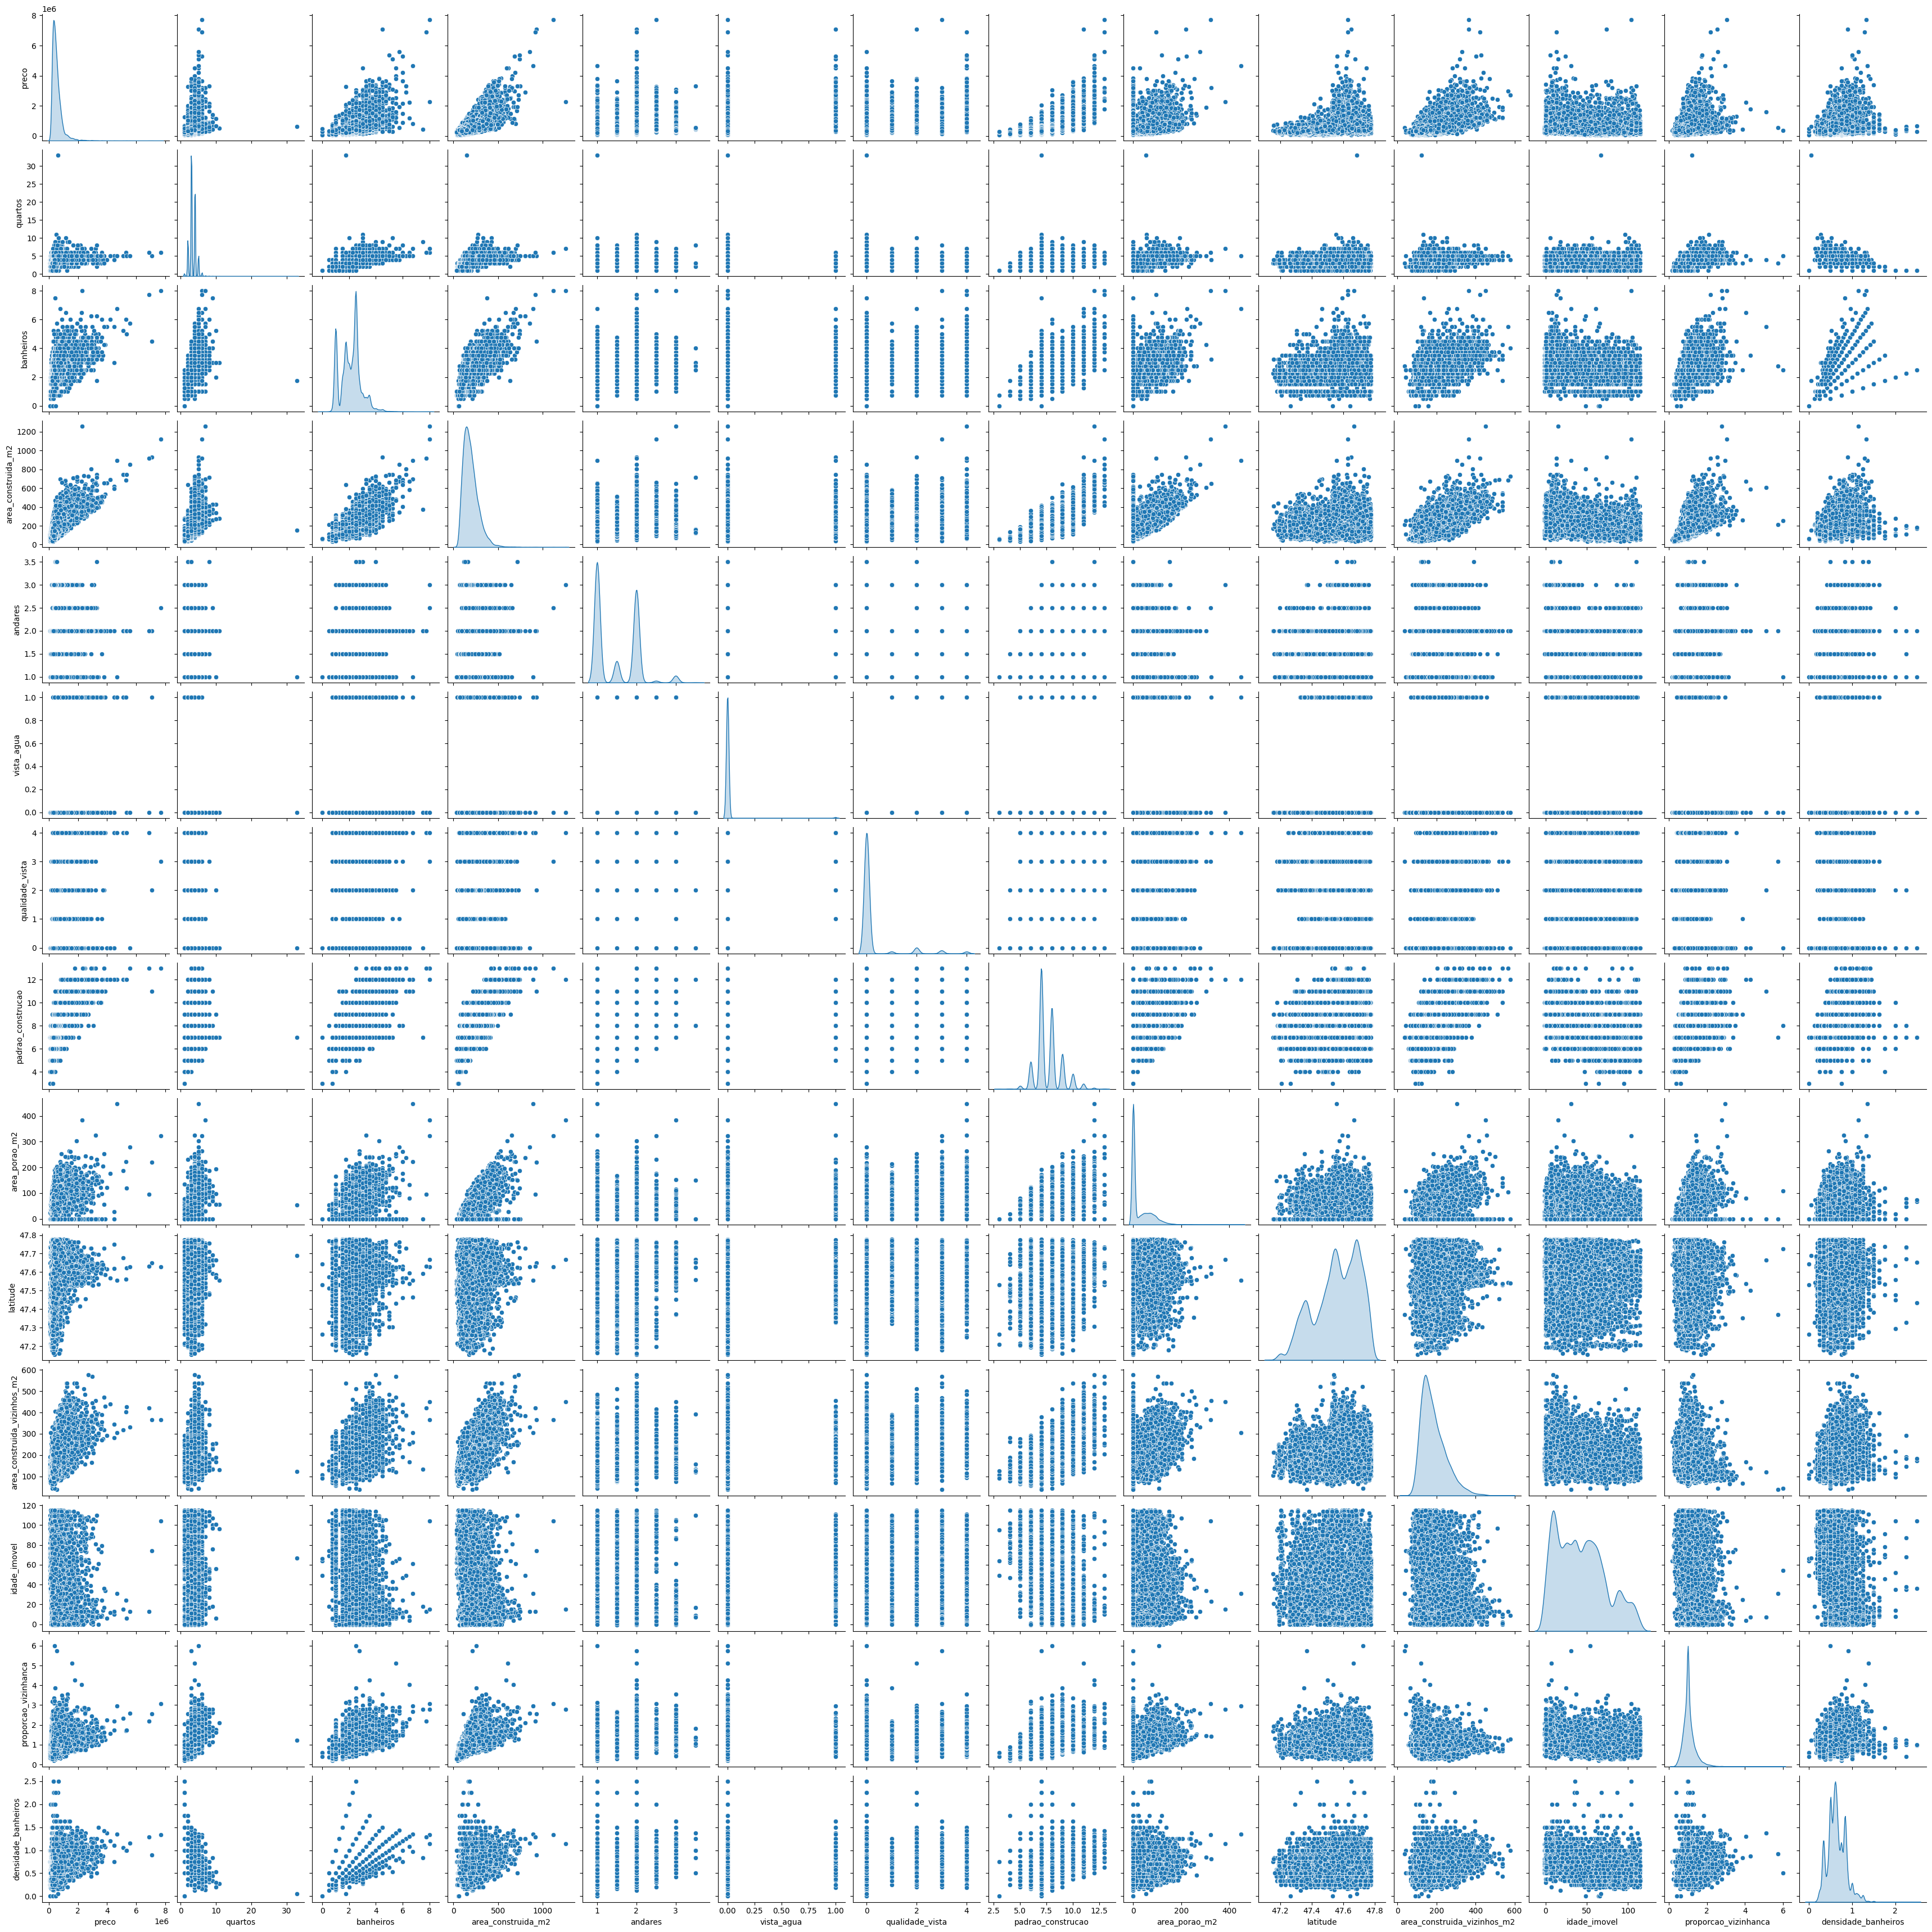

In [39]:
sns.pairplot(df_modelo, diag_kind='kde')
plt.show()

In [40]:
#x = df_modelo.drop(columns = 'preco')
#y = df_modelo['preco']
#x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 40)
#modelo = LinearRegression()
#modelo.fit(x_train, y_train)
#previsoes = modelo.predict(x_test)

In [41]:
#Uso o r2_score para analisar quao bem a minha regressão consegue explicar a variação dos dados
#r2 = r2_score(y_test, previsoes)
#mae = mean_absolute_error(y_test, previsoes)
#rmse = np.sqrt(mean_squared_error(y_test, previsoes))
 # calcula o módulo do erro e calcula-se a média(menos sensível a outliers)
#print(f'Erro médio absoluto: {mae:.2f}') # foca em erros médios típicos
# calcula o erro de cada previsão, eleva ao quadrado e calcula a média, após isso calcula a raiz desse resultado para voltarmos para a unidade de medida original(diferenciavel, facilita o ajuste de parametros, penaliza o modelo pelos outliers)
#print(f'Erro médio quadrático: {rmse:.2f}') # foca em erros grandes
#print(f"Acurácia: {r2:.2f}")

In [42]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import joblib

# Separação de X e y
x = df_modelo.drop(columns='preco')
y = df_modelo['preco']

# Separando dados de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

#  Normalizando os dados
scaler = MinMaxScaler()
scaler.set_output(transform="pandas")

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

# Transformando em polinomio
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled) 

# Treinando o modelo
modelo = LinearRegression()
modelo.fit(x_train_poly, y_train)

# Métricas
previsoes = modelo.predict(x_test_poly)

acuracia = r2_score(y_test, previsoes)
mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))

print(f'Erro médio absoluto (MAE): ${mae:,.2f}')
print(f'Erro médio quadrático (RMSE): ${rmse:,.2f}')
print(f"Acurácia (R²): {acuracia:.2%}")

# 7. SALVAR TODOS OS ARTEFATOS DO PIPELINE
joblib.dump(scaler, '../machine_learning/scaler.pkl')
joblib.dump(poly, '../machine_learning/transformador_poly.pkl')
joblib.dump(modelo, '../machine_learning/modelo_polinomial.pkl')


Erro médio absoluto (MAE): $103,698.84
Erro médio quadrático (RMSE): $163,115.08
Acurácia (R²): 78.02%


['../machine_learning/modelo_polinomial.pkl']

In [43]:
#import plotly.graph_objects as go
#import numpy as np

# 1. Definir os limites para a linha de "Acerto Perfeito"
#min_val = min(y_test.min(), previsoes.min())
#max_val = max(y_test.max(), previsoes.max())

# 2. Criar a figura
#fig = go.Figure()

# 3. Adicionar os pontos (Scatter)
#fig.add_trace(go.Scatter(
 #   x=y_test, 
 #   y=previsoes,
 #   mode='markers',
 #   marker=dict(color='royalblue', opacity=0.5),
 #   name='Previsões do Modelo',
 #   hovertemplate='<b>Preço Real:</b> $%{x:,.2f}<br><b>Previsão:</b> $%{y:,.2f}<extra></extra>'
#))

# 4. Adicionar a linha de "Acerto Perfeito" (y = x)
#fig.add_trace(go.Scatter(
#    x=[min_val, max_val], 
#    y=[min_val, max_val],
#    mode='lines',
#    line=dict(color='tomato', dash='dash', width=3),
#    name='Acerto Perfeito (Real = Previsto)'
#))

# 5. Configurar o layout e formatação de eixos
#fig.update_layout(
#    title='<b>Avaliação do Modelo: Preço Real vs. Preço Previsto</b>',
#    xaxis_title='Preço Real do Imóvel ($)',
#    yaxis_title='Preço Previsto pelo Modelo ($)',
#    template='plotly_white',
#    width=900,
#    height=600,
#   legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
#)

# Formatação para aparecer em Milhões ou Milhares nos eixos
#fig.update_xaxes(tickformat="$.2s")
#fig.update_yaxes(tickformat="$.2s")

# Exibir o gráfico
#fig.show()

In [44]:
import plotly.graph_objects as go

# 1. Pegando os dados da Célula 4 (Polinomial)
# 'previsoes' já contém os resultados do modelo polinomial
limites_poly = [y_test.min(), y_test.max()]

# 2. Criar a figura
fig_poly = go.Figure()

# Pontos de previsão
fig_poly.add_trace(go.Scatter(
    x=y_test, y=previsoes,
    mode='markers',
    marker=dict(color='royalblue', opacity=0.5),
    name='Previsão Polinomial'
))

# Linha de Acerto Perfeito
fig_poly.add_trace(go.Scatter(
    x=limites_poly, y=limites_poly,
    mode='lines',
    line=dict(color='black', dash='dash'),
    name='Ideal'
))

fig_poly.update_layout(
    title=f'Regressão Polinomial)',
    xaxis_title='Preço Real',
    yaxis_title='Preço Previsto',
    template='plotly_white',
    width=700, height=500
)

fig_poly.update_xaxes(tickformat="$.2s")
fig_poly.update_yaxes(tickformat="$.2s")

fig_poly.show()

## 4.1 Experimentos com redes neurais

### 4.1.1 Configurando MLFlow para tracking dos experimentos


In [45]:
#import mlflow
#mlflow.set_experiment("First Experiment")
#mlflow.set_tracking_uri("http://127.0.0.1:5000")

#with mlflow.start_run():
    #mlflow.log_params(parametros do modelo)
    #mlflow.log_metrics(metricas do modelo( pode passar em dicionario))
    #mlflow.sklearn.log_model()




In [46]:
# uma outra forma de fazer seria fazer os experimentos, colocar em um dicionario e percorrê-los para depois registrá-los
#mlflow.set_experiment(nome experimento)
#mlflow.set_tracking_uri(uri = uri)

#experimentos = [{
    #nome: ,
    #lr: ,
    #batch_size: ,
    #loss: ,
    #acc: ,
#},
#{
    #nome: ,
    #lr: ,
    #batch_size: ,
    #loss: ,
    #acc: , 
#}]

#for exp in experimentos:
    #model_name = exp['nome']
    #learning_rate = exp['lr']
    #batch_size = exp['batch_size']

    #with mlflow.start_run(run_name = model_name):
        #mlflow.log_param("model_name", model_name)
        #mlflow.log_param("learning_rate", learning_rate)
        #mlflow.log_param("batch_size", batch_size)

    ## 2. Registo manual das métricas de desempenho obtidas após o treino
        #mlflow.log_metric("loss", exp["loss_final"])
        #mlflow.log_metric("accuracy", exp["acc_final"])

    ## 3. Registo manual do modelo PyTorch no MLflow
        #mlflow.pytorch.log_model(pytorch_model=model, artifact_path="model")


In [47]:
## Registrar o modelo selecionado para o MLFlow
#model_name = 'nome_do_modelo'
#run_id = input("enter Run ID:")
#model_uri = f"runs:/{run_id}/model" # antes o ultimo caminho era {model_name}, mas não estava funcionando, logo mudamos para 'model' e funcionou

#result = mlflow.register_model(
#    model_uri, model_name
#)

In [48]:
## Carregar o modelo do MLFlow para o meu notebook
#model_version = 1
#model_uri = f'models:/{model_name}@challenger' # outra forma seria colocar f'models:/{model_name}/{model_version}, fizemos do outro jeito para não precisar ficar lembrando as versoes do modelo

#loaded_model = mlflow.pytorch.load_model(model_uri)
#y_pred = loaded_model(X_test)
#y_pred[:4]

In [49]:
# Como fazer a transição do ambiente de desenvolvimento para o ambiente de produção?
#dev_model_uri = f'models:/{model_name}@challenger' 
#prod_model = 'anomaly-detection-prod'
#client = mlflow.MlflowClient()
#client.copy_model_version(src_model_uri = dev_model_uri, dst_name = prod_model)

In [50]:
## Carregando o meu modelo de produção(champoion)
#model_uri = f'models:/{prod_model}@champion' # outra forma seria colocar f'models:/{model_name}/{model_version}, fizemos do outro jeito para não precisar ficar lembrando as versoes do modelo

#loaded_model = mlflow.pytorch.load_model(model_uri)
#y_pred = loaded_model(X_test)
#y_pred[:4]

Nota: Se estiver com mais pessoas trabalhando no mesmo projeto usar o Dagshub, para isso devemos criar um repositorio no github, depois podemos adicionar o nosos notebook com o modelo nesse repositorio, depois disso só ir ao Dagshub(cirar uma conta de não tiver uma) conectar a um repositorio existente no github e depois criar uma célula para a configuração do Dagshub

In [51]:
## Configuração dagshub
#import dagshub
#dagshub.init(repo_owner = dono_repositorio, repo_name = nome_repositorio, mlflow = True)

In [52]:
#import os
# os.environ['MLFLOW_TRACKING_USERNAME] = 'nome_usuario'
# os.environ['MLFLOW_TRACKING_PASSWORD] = 'senha_usuario'
# os.environ['MLFLOW_TRACKING_URI] = 'url_dagshub'
#mlflow.set_experiment(nome experimento)

#mlflow.set_tracking_uri('url_dagshub')

#for exp in experimentos:
    #model_name = exp['nome']
    #learning_rate = exp['lr']
    #batch_size = exp['batch_size']

    #with mlflow.start_run(run_name = model_name):
        #mlflow.log_param("model_name", model_name)
        #mlflow.log_param("learning_rate", learning_rate)
        #mlflow.log_param("batch_size", batch_size)

    ## 2. Registo manual das métricas de desempenho obtidas após o treino
        #mlflow.log_metric("loss", exp["loss_final"])
        #mlflow.log_metric("accuracy", exp["acc_final"])

    ## 3. Registo manual do modelo PyTorch no MLflow
        #mlflow.pytorch.log_model(pytorch_model=model, artifact_path="model")


## 6.2 Experimentos da rede neural


In [53]:
type(x_train_scaled), type(x_test_scaled), type(y_train), type(y_test)

(pandas.DataFrame, pandas.DataFrame, pandas.Series, pandas.Series)

In [54]:
import torch
from torch import nn
X_train, y_train = torch.tensor(x_train_scaled.to_numpy(), dtype = torch.float32), torch.tensor(y_train.to_numpy(), dtype = torch.float32)
X_test, y_test = torch.tensor(x_test_scaled.to_numpy(), dtype = torch.float32), torch.tensor(y_test.to_numpy(), dtype = torch.float32)
X_train.shape, y_train.shape

(torch.Size([17280, 13]), torch.Size([17280]))

In [55]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)


train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = 32,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_dataset,
                             batch_size = 32,
                             shuffle = False)

len(train_dataloader), len(test_dataloader)

(540, 135)

In [56]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [57]:
import torch
from torch import nn

class RedeNeuralV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 13, out_features = 64)
        self.relu1 = nn.ReLU()
        self.layer_2 = nn.Linear(in_features = 64, out_features = 32)
        self.relu2 = nn.ReLU()
        self.layer_3 = nn.Linear(in_features = 32, out_features = 1)
    def forward(self,x):
        return self.layer_3(self.relu2(self.layer_2(self.relu1(self.layer_1(x)))))

model_1 = RedeNeuralV1().to(device= device)

In [58]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),
                             lr = 0.01)

In [ ]:
from torchmetrics.regression import R2Score
import mlflow
import os


os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true" # Cria uma variavel local para dar permissão para o mlflow usar o sistema de arquivos local
mlflow.set_tracking_uri("file:./mlruns") # Cria uma pasta chamada mlruns no nivel atual para armazenar o histórico

mlflow.set_experiment("Experimento_RedeNeuralV1") # Nome do experimento
mlflow.pytorch.autolog() # Tracking automático de hyperparâmetros e artefatos do pytorch


torch.manual_seed(42) # define a seed(cpu)
torch.cuda.manual_seed(42) # define a seed (gpu)


r2_train_metric = R2Score().to(device) # instancia a metrica r2 para treino e envia para o dispositivo de destino
r2_test_metric = R2Score().to(device) # instancia metrica r2 para teste e envia para o dispositivo de destino
epochs = 200 # numero de epocas

with mlflow.start_run(run_name = "RedeNeuralV1_200_Epochs"): # Abre um bloco de execução com o nome RedeNeuralV1_200_Epochs no mlflow
    for epoch in range(epochs): # percorre as épocas
        r2_train_metric.reset() # reseta os acumuladores a cada época para que o calculo do r2 anterior nao interfira no calculo do proximo
        r2_test_metric.reset() # reseta os acumuladores a cada época para que o calculo do r2 anterior nao interfira no calculo do proximo

    
        train_loss = 0 # Inicializa a perda do treino em 0 

        for batch, (X,y) in enumerate(train_dataloader): # desempacota o dataloader e pega o batch e a tupla de (X,y)
            X, y = X.to(device), y.to(device) # envia as entradas e a saída para o dispositivo de destino
            model_1.train() # Coloca o modelo em modo de treinamento
            y_pred = model_1(X) # forward pass (inferencia)

            loss = loss_fn(y_pred.squeeze(), y) # calcula a perda
            train_loss += loss.item() # acumula a perda total de treino
            r2_train_metric.update(y_pred.squeeze(), y.squeeze()) # envio o y_pred e o y para assim calcular o r2

            optimizer.zero_grad() # zera os gradientes para depois atualizá-los

            loss.backward() # backpropagation

            optimizer.step() # Passo do otimizador

        train_loss /=len(train_dataloader) # Divide para obter a perda média do treino
        r2_train_score = max(0, r2_train_metric.compute().item()) * 100 

        test_loss = 0 # Inicia a perda do teste em 0 
        model_1.eval() # Coloca o modelo em modo de avaliação

        with torch.inference_mode(): # Liga o modo de inferencia 
            for X_test, y_test in test_dataloader:  
                X_test, y_test = X_test.to(device), y_test.to(device) # envio os dados de teste para o dispositivo de destino  

                test_pred = model_1(X_test) # forward pass (inferencia)

                test_loss += loss_fn(test_pred.squeeze(), y_test).item()  # retiro a dimensão de saída usando squeeze ([32,1]) -> ([32]) para comparar com os rotulos de saida 
                r2_test_metric.update(test_pred.squeeze(), y_test.squeeze()) # retiro a dimensão extra do test_pred e do y_test(se houver) para calcular o r2

            test_loss /= len(test_dataloader) # obtem a perda media do teste
            r2_test_score = max(0,r2_test_metric.compute().item()) * 100 


            mlflow.log_metric("r2_train_percent", r2_train_score, step=epoch) # step = epoch é para quando for olhar o mlflow ele mostrar a evolução do r2score
            mlflow.log_metric("r2_test_percent", r2_test_score, step=epoch) # step = epoch é para quando for olhar o mlflow ele mostrar a evolução do r2score
            mlflow.log_metric("train_loss_mse", train_loss, step=epoch) # step = epoch é para quando for olhar o mlflow ele mostrar a evolução do r2score
            mlflow.log_metric("test_loss_mse", test_loss, step=epoch) # step = epoch é para quando for olhar o mlflow ele mostrar a evolução do r2score

        if (epoch + 1) % 10 == 0: # printa a cada 10 épocas

            print(f"Época {epoch + 1}")
            print(f"Perda do treino(MSE): {train_loss:.4f} | Perda no teste(MSE): {test_loss:.4f} | R2 treino: {r2_train_score:.2f}% | R2 teste: {r2_test_score:.2f}%")

Época 10
Perda do treino(MSE): 48478931501.5111 | Perda no teste(MSE): 39896319795.2000 | R2 treino: 64.92% | R2 teste: 67.04%
Época 20
Perda do treino(MSE): 40896141208.6519 | Perda no teste(MSE): 33860058885.6889 | R2 treino: 70.40% | R2 teste: 72.03%
Época 30
Perda do treino(MSE): 36421367673.3630 | Perda no teste(MSE): 31451255743.5259 | R2 treino: 73.64% | R2 teste: 74.02%
Época 40
Perda do treino(MSE): 34976684711.8222 | Perda no teste(MSE): 31119186356.1481 | R2 treino: 74.69% | R2 teste: 74.29%
Época 50
Perda do treino(MSE): 34258884790.9926 | Perda no teste(MSE): 30046905837.0370 | R2 treino: 75.21% | R2 teste: 75.18%
Época 60
Perda do treino(MSE): 33557769723.2593 | Perda no teste(MSE): 29777912593.0667 | R2 treino: 75.71% | R2 teste: 75.40%
Época 70
Perda do treino(MSE): 32985960253.6296 | Perda no teste(MSE): 29317552363.1407 | R2 treino: 76.13% | R2 teste: 75.78%
Época 80
Perda do treino(MSE): 32394008390.1630 | Perda no teste(MSE): 29146629028.9778 | R2 treino: 76.56% | R

# 5. Deploy


In [60]:
df_modelo.tail()

,preco,quartos,banheiros,area_construida_m2,andares,vista_agua,qualidade_vista,padrao_construcao,area_porao_m2,latitude,area_construida_vizinhos_m2,idade_imovel,proporcao_vizinhanca,densidade_banheiros
21595,360000.0,3,2.50,142.141789,3.0,0,0,8,0.0,47.6993,142.141789,5,1.000000,0.833333
21596,400000.0,4,2.50,214.606230,2.0,0,0,8,0.0,47.5107,170.012728,1,1.262295,0.625000
21597,402101.0,2,0.75,94.761193,2.0,0,0,7,0.0,47.5944,94.761193,5,1.000000,0.375000
21598,400000.0,3,2.50,148.645008,2.0,0,0,8,0.0,47.5345,130.993413,11,1.134752,0.833333
21599,325000.0,2,0.75,94.761193,2.0,0,0,7,0.0,47.5941,94.761193,6,1.000000,0.375000


In [61]:
import pandas as pd
import joblib

# 1. Carrega os arquivos binários de volta para a memória
modelo_carregado = joblib.load('../machine_learning/modelo_polinomial.pkl')
poly_carregado = joblib.load('../machine_learning/transformador_poly.pkl')
scaler_carregado = joblib.load('../machine_learning/scaler.pkl')
# 2. Dados da nova casa (exatamente como no seu dataframe original)
nova_casa = {
    'quartos': 3,
    'banheiros': 2.5,
    'area_construida_m2': 180,
    'andares': 2,
    'vista_agua': 0,
    'qualidade_vista': 0,
    'padrao_construcao': 7,
    'area_porao_m2': 0,
    'latitude': 47.5112,
    'area_construida_vizinhos_m2': 170,
    'idade_imovel': 4,
    'proporcao_vizinhanca': 1.05,
    'densidade_banheiros': 0.833

}

# 3. Convertendo para DataFrame
df_input = pd.DataFrame([nova_casa])

df_input_scaled = scaler_carregado.transform(df_input)

# --- O PASSO MAIS IMPORTANTE ---
# Transforma as 11 colunas originais em colunas polinomiais (ex: cria os quadrados e interações)
# O modelo só aceita os dados se eles passarem por aqui primeiro
df_input_poly = poly_carregado.transform(df_input_scaled)

# 4. Fazer a previsão usando os dados transformados
predicao = modelo_carregado.predict(df_input_poly)

print(f"O preço estimado para este imóvel é: ${predicao[0]:,.2f}")

O preço estimado para este imóvel é: $430,349.75
